<a href="https://colab.research.google.com/github/HosseinMasoudi/Sentiment_Analysis_with_Transformers/blob/master/SentimentAnalysisTransformersNLP(WithOutHazm)(Use_Model_in_MLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [2]:
!pip install num2fawords
!pip install parsivar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 42.2 MB/s eta 0:00:00


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf
import transformers
import JackageNormalizer

from parsivar import Tokenizer
from JackageNormalizer import normalize_persian_text

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

from tensorflow.keras import layers, Model ,Input
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
from tensorflow.keras import regularizers

from transformers import pipeline
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, AutoConfig
from transformers import DataCollatorWithPadding
from transformers import DistilBertTokenizerFast
from transformers import TFDistilBertForSequenceClassification
from transformers import TFAutoModel

import tqdm as notebook_tqdm

In [4]:
model_name = "HooshvareLab/bert-fa-base-uncased"

testing the pip line...

In [5]:
# Use a pipeline as a high-level helper
pipe = pipeline("text-classification", model=model_name)
# Example usage of the pipeline
result = pipe("این غذا خیلی خوشمزه بود!")
print(result)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at HooshvareLab/bert-fa-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


[{'label': 'LABEL_1', 'score': 0.5193586349487305}]


### 1. Load and Inspect Your Dataset

In [6]:
df = pd.read_csv("/content/cleaned_snappfood copy.csv")
df.head()

,comment,label,comment_length,comment_cleaned
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,0,47,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,1,132,قرار بود ساعته برسه ولی نیم ساعت زودتر از موق...
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,0,89,قیمت این مدل اصلا با کیفیتش سازگاری نداره فقط ...
3,عالی بود همه چه درست و به اندازه و کیفیت خوب، ...,1,99,عالی بود همه چه درست و به اندازه و کیفیت خوب ا...
4,شیرینی وانیلی فقط یک مدل بود.,1,29,شیرینی وانیلی فقط یک مدل بود


In [7]:
df.info()
df.isnull().count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65973 entries, 0 to 65972
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   comment          65973 non-null  object
 1   label            65973 non-null  int64 
 2   comment_length   65973 non-null  int64 
 3   comment_cleaned  65973 non-null  object
dtypes: int64(2), object(2)
memory usage: 2.0+ MB


,0
comment,65973
label,65973
comment_length,65973
comment_cleaned,65973


In [8]:
print(df.shape)
print(df.columns)

(65973, 4)
Index(['comment', 'label', 'comment_length', 'comment_cleaned'], dtype='object')


In [9]:
df = df[['comment', 'label']]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [10]:
tokenizer = Tokenizer()

def clean_text(text):
    text = normalize_persian_text(text)
    tokens = tokenizer.tokenize_words(text)
    return ' '.join(tokens)


In [11]:
df['comment'] = df['comment'].apply(clean_text)

df['comment'].sample(20)

,comment
16842,شور بودن غذا سرد بودن غذا
5644,عالی بود تازه خوشمزه حدود پانزده دقیقه طول کشی...
7888,همه چی عالی داغ موقع کیفیت
22426,نانهای کاملا بیکیفیت بطوریکه نصفشون موقع رسیدن...
44874,همه چیز خیلی خوب خیلی طول کشید برسه
31113,سالاد خیلی حجمش کم مواد اولیه بیکیفیت شده
61528,مثل همیشه عالی تازه
1490,کروسان شکلاتی تازه نبود رساندن تاخیر وجود
27392,کیفیت خیلی خوب بود میشد شیرین فروشیها خامه صنع...
55629,لطفا زمان ارسال دقت دو ساعت نیم زودتر سفارش رو...


#### Split into train / val / test

In [12]:
texts = df['comment'].tolist()
labels = df['label'].values

In [13]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

70% → train

15% → validation

15% → test

In [14]:
classes = np.unique(train_labels)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=train_labels)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weights:", class_weight)

Class weights: {0: 1.0218844043193485, 1: 0.9790332838668645}


In [15]:
print(f"Train shape: {len(train_texts)}, Validation shape: {len(val_texts)}, Test shape: {len(test_texts)}\n")

print("Data loaded and processed successfully.")
print(f"Sample of cleaned text:\n ({train_texts[0]}) \n label: {train_labels[0]}")

Train shape: 46181, Validation shape: 9896, Test shape: 9896

Data loaded and processed successfully.
Sample of cleaned text:
 (سیبزمینی روغن مونده درست بو میداد قابل خوردن شکل شمایلش خوب نبود) 
 label: 0


### 2. Prepare Text and Tokenize

In [16]:
model_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [17]:
def encode_texts(texts):
    return model_tokenizer(list(texts), truncation=True, padding=True, max_length=128)

In [18]:
train_encoded = encode_texts(train_texts)
val_encoded = encode_texts(val_texts)
test_encoded = encode_texts(test_texts)

convert Encoding to TF DataSet

In [19]:
def make_tf_dataset(encoding, labels, shuffle=False, BATCH_SIZE=16):
    encoding = {"input_ids": encoding["input_ids"], "attention_mask": encoding["attention_mask"]}
    dataset = tf.data.Dataset.from_tensor_slices((encoding, labels))
    if shuffle:
        dataset = dataset.shuffle(1000)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [20]:
train_dataset = make_tf_dataset(train_encoded, train_labels, shuffle=True)
val_dataset = make_tf_dataset(val_encoded, val_labels)
test_dataset = make_tf_dataset(test_encoded, test_labels)

In [21]:
for batch_x, batch_y in train_dataset.take(1):
    print("Batch X keys:", batch_x.keys())
    print("input_ids shape:", batch_x["input_ids"].shape)
    print("attention_mask shape:", batch_x["attention_mask"].shape)
    print("Labels shape:", batch_y.shape)
    print("Labels:", batch_y.numpy())

Batch X keys: dict_keys(['input_ids', 'attention_mask'])
input_ids shape: (16, 79)
attention_mask shape: (16, 79)
Labels shape: (16,)
Labels: [1 0 0 0 0 0 1 1 1 0 1 0 0 1 0 0]


In [22]:
sample_ids = batch_x["input_ids"][0].numpy()
decoded_text = model_tokenizer.decode(sample_ids, skip_special_tokens=True)
print("Decoded text:", decoded_text)
print("Label:", batch_y[0].numpy())

Decoded text: اب هویچش خیلی عالی بود اب سیب خیلی شیرین انگار خیلی شکر ریختن
Label: 1


### 3. Laod the Model_Compile the Model_Train the Model

Model architecture:
1. Inputs (all from tf.keras)
2. Transformer backbone (freeze the backbone completely)
3. Extract sentence representation (choose one option)
4. Head (MLP classifier)

In [23]:
def build_sentiment_model(model_name: str):

    input_ids      = Input(shape=(None,), dtype=tf.int32, name="input_ids")
    attention_mask = Input(shape=(None,), dtype=tf.int32, name="attention_mask")

    transformer = TFAutoModel.from_pretrained(model_name)
    transformer.trainable = False

    outputs = transformer(input_ids=input_ids, attention_mask=attention_mask)
    cls = outputs.pooler_output

    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-5), name="Dense")(cls)
    x = layers.Dropout(0.3, name="Dropout")(x)
    logits = layers.Dense(1, activation="sigmoid", dtype="float16", name="OutputSigmoid")(x)

    model = Model(inputs=[input_ids, attention_mask], outputs=logits)
    return model

model = build_sentiment_model(model_name)

model.summary()

tf_model.h5:   0%|          | 0.00/963M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at HooshvareLab/bert-fa-base-uncased were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at HooshvareLab/bert-fa-base-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for pred

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   1628413   ['input_ids[0][0]',           
 )                           ngAndCrossAttentions(last_   44         'attention_mask[0][0]']      
                             hidden_state=(None, None,                                        

### Stage 1: compile + callbacks + fit

optimizer with AdamW

In [24]:
optimizer_adamW = tf.keras.optimizers.AdamW(
    learning_rate=1e-5,
    weight_decay=0.01,
    clipnorm=1.0,
)

model.compile(
    optimizer=optimizer_adamW,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

optimizer with Adam

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3, clipnorm=1.0),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

CallBack

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_model_stage1.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
]

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/functional.py:641: UserWarning: Input dict contained keys ['token_type_ids'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


2886/2887 [============================>.] - ETA: 0s - loss: 0.5739 - accuracy: 0.6990

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


2887/2887 [==============================] - 379s 125ms/step - loss: 0.5739 - accuracy: 0.6990 - val_loss: 0.4760 - val_accuracy: 0.7872 - lr: 1.0000e-05
Epoch 2/20
2887/2887 [==============================] - 359s 124ms/step - loss: 0.4964 - accuracy: 0.7625 - val_loss: 0.4465 - val_accuracy: 0.8009 - lr: 1.0000e-05
Epoch 3/20
2887/2887 [==============================] - 354s 123ms/step - loss: 0.4767 - accuracy: 0.7768 - val_loss: 0.4358 - val_accuracy: 0.8025 - lr: 1.0000e-05
Epoch 4/20
2887/2887 [==============================] - 343s 119ms/step - loss: 0.4690 - accuracy: 0.7809 - val_loss: 0.4295 - val_accuracy: 0.8085 - lr: 1.0000e-05
Epoch 5/20
2887/2887 [==============================] - 360s 125ms/step - loss: 0.4645 - accuracy: 0.7848 - val_loss: 0.4250 - val_accuracy: 0.8117 - lr: 1.0000e-05
Epoch 6/20
2887/2887 [==============================] - 369s 128ms/step - loss: 0.4583 - accuracy: 0.7878 - val_loss: 0.4210 - val_accuracy: 0.8117 - lr: 1.0000e-05
Epoch 7/20
2887/2887 

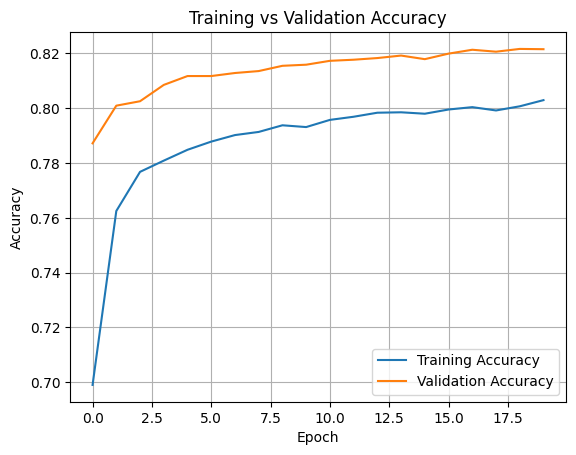

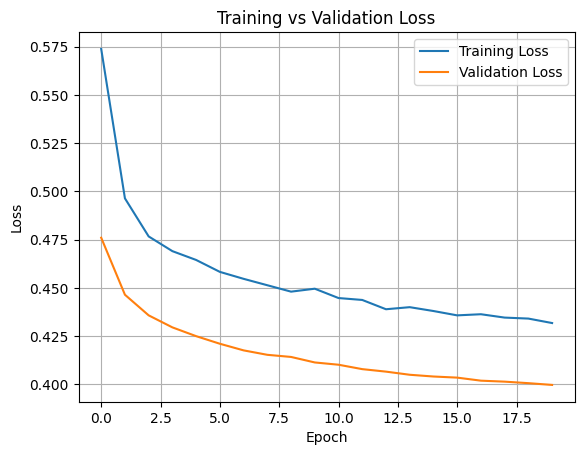

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


### Stage 2: unfreeze last 2 encoder layers + small LR

In [25]:
backbone = next((lyr for lyr in model.layers if hasattr(lyr, "bert")), None)
if backbone is not None:
    backbone.trainable = True
    try:
        enc_layers = backbone.bert.encoder.layer
        n = len(enc_layers)
        for i, enc in enumerate(enc_layers):
            enc.trainable = (i >= n-2)
        print("Unfroze last 2 encoder layers.")
    except Exception as e:
        print("WARN: per-layer flag failed, unfreezing whole backbone.", e)
        backbone.trainable = True
else:
    print("WARN: backbone not found – training head only.")


Unfroze last 2 encoder layers.


In [26]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   1628413   ['input_ids[0][0]',           
 )                           ngAndCrossAttentions(last_   44         'attention_mask[0][0]']      
                             hidden_state=(None, None,                                        

compile

In [27]:
optimizer_adamW_stage2 = tf.keras.optimizers.AdamW(learning_rate=5e-6, weight_decay=0.01, clipnorm=1.0)

model.compile(
    optimizer=optimizer_adamW_stage2,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

CallBack

In [48]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_model_weights(stage2).h5",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6
    ),
]

Fit

In [29]:
history_2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/10
2887/2887 [==============================] - ETA: 0s - loss: 0.4140 - accuracy: 0.8155 - auc: 0.8880 - precision: 0.8566 - recall: 0.7672

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


2887/2887 [==============================] - 562s 185ms/step - loss: 0.4140 - accuracy: 0.8155 - auc: 0.8880 - precision: 0.8566 - recall: 0.7672 - val_loss: 0.3440 - val_accuracy: 0.8566 - val_auc: 0.9254 - val_precision: 0.9098 - val_recall: 0.7984 - lr: 5.0000e-06
Epoch 2/10
2887/2887 [==============================] - 609s 211ms/step - loss: 0.3525 - accuracy: 0.8497 - auc: 0.9202 - precision: 0.8919 - recall: 0.8030 - val_loss: 0.3293 - val_accuracy: 0.8634 - val_auc: 0.9320 - val_precision: 0.9012 - val_recall: 0.8227 - lr: 5.0000e-06
Epoch 3/10
2887/2887 [==============================] - 584s 202ms/step - loss: 0.3313 - accuracy: 0.8604 - auc: 0.9298 - precision: 0.9006 - recall: 0.8168 - val_loss: 0.3251 - val_accuracy: 0.8663 - val_auc: 0.9353 - val_precision: 0.9002 - val_recall: 0.8302 - lr: 5.0000e-06
Epoch 4/10
2887/2887 [==============================] - 595s 206ms/step - loss: 0.3141 - accuracy: 0.8687 - auc: 0.9371 - precision: 0.9071 - recall: 0.8277 - val_loss: 0.321

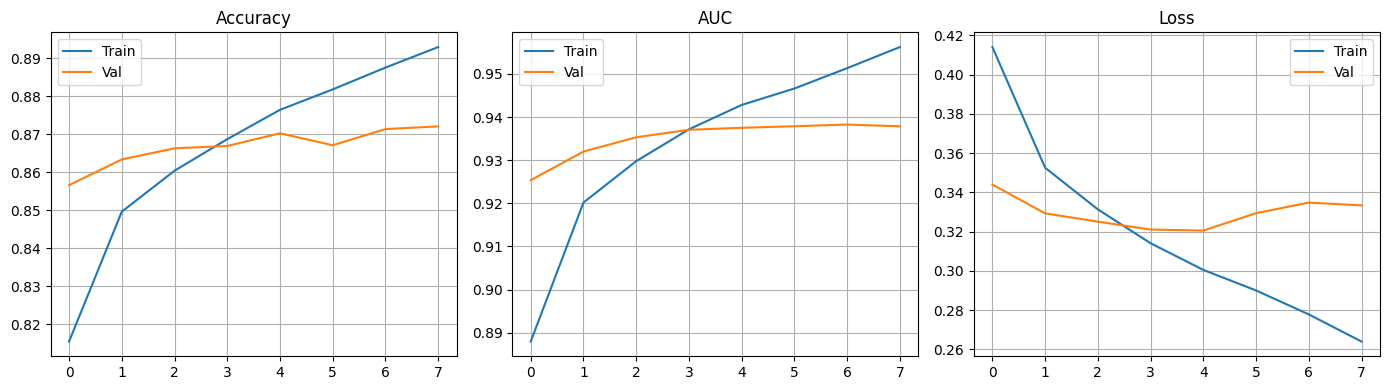

In [30]:
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(history_2.history['accuracy'], label='Train')
plt.plot(history_2.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(history_2.history['auc'], label='Train')
plt.plot(history_2.history['val_auc'], label='Val')
plt.title('AUC')
plt.legend()
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(history_2.history['loss'], label='Train')
plt.plot(history_2.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### (Previous version of the model)

Since the output of the SequenceClassification model was fixed and cannot be used in a feed-forward network, we must use the original parsBert model itself.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("HooshvareLab/bert-fa-base-uncased-sentiment-snappfood")

In [ ]:
model = TFAutoModelForSequenceClassification.from_pretrained(
    "HooshvareLab/bert-fa-base-uncased-sentiment-snappfood",
    num_labels=2,
    use_safetensors=True)

### 4. Evaluate on TEST set

In [31]:
print("Final Evaluation on Test Set\n")
metrics = model.evaluate(test_dataset, return_dict=True, verbose=1)
print(metrics)

print("Loss:", metrics["loss"])
print("Accuracy:", metrics["accuracy"])
print("AUC:", metrics["auc"])
print("Precision:", metrics["precision"])
print("Recall:", metrics["recall"])

Final Evaluation on Test Set

619/619 [==============================] - 36s 48ms/step - loss: 0.3412 - accuracy: 0.8612 - auc: 0.9305 - precision: 0.9080 - recall: 0.8092
{'loss': 0.3412115275859833, 'accuracy': 0.8611560463905334, 'auc': 0.930507242679596, 'precision': 0.9079768061637878, 'recall': 0.8091739416122437}
Loss: 0.3412115275859833
Accuracy: 0.8611560463905334
AUC: 0.930507242679596
Precision: 0.9079768061637878
Recall: 0.8091739416122437


### 5. Save the Fine-Tuned Model